# Kochi Urban Mobility – Exploratory Analysis

## Step 1: Load the data

Load the five analysis tables (the star schema in the `public` schema), describe what each one holds, and summarise what period and roads the data covers.

In [1]:
from pathlib import Path

import pandas as pd

DATA_DIR = Path("../data/exports/public")

travel = pd.read_csv(DATA_DIR / "fact_travel_time.csv")
weather = pd.read_csv(DATA_DIR / "fact_weather.csv")
corridors = pd.read_csv(DATA_DIR / "dim_corridor.csv")
dates = pd.read_csv(DATA_DIR / "dim_date.csv")
times = pd.read_csv(DATA_DIR / "dim_time.csv")

# --- What each table holds ---------------------------------------------
tables = {
    "fact_travel_time": (travel, "one traffic reading for one corridor at one moment"),
    "fact_weather": (weather, "one hour of Kochi weather"),
    "dim_corridor": (corridors, "one road stretch in one direction"),
    "dim_date": (dates, "one calendar day"),
    "dim_time": (times, "one hour of the day"),
}

print("TABLES LOADED")
print("-" * 80)
for name, (df, row_meaning) in tables.items():
    print(f"{name:<18} {len(df):>6,} rows x {df.shape[1]:>2} cols   1 row = {row_meaning}")

# --- What period and roads the data covers ------------------------------
pulled_at = pd.to_datetime(travel["pulled_at_ist"])
observed_at = pd.to_datetime(weather["observation_time_ist"])
n_corridors = travel["corridor_id"].nunique()
n_pulls = pulled_at.nunique()
n_missing = n_pulls * n_corridors - len(travel)

print("\nWHAT THE DATA COVERS")
print("-" * 80)
print(f"Traffic period   : {pulled_at.min():%d %b %Y %H:%M} -> {pulled_at.max():%d %b %Y %H:%M}"
      f"  ({travel['date_key'].nunique()} days)")
print(f"Traffic pulls    : {n_pulls:,} API pulls x {n_corridors} corridors"
      f" = {n_pulls * n_corridors:,} expected, {n_missing} missing")
print(f"Corridors        : {n_corridors} one-way corridors, ~{len(travel) / n_corridors:.0f} readings each")
print(f"Weather period   : {observed_at.min():%d %b %Y %H:%M} -> {observed_at.max():%d %b %Y %H:%M}"
      f"  ({len(weather)} hourly readings = {len(weather) / 24:.0f} days)")
print(f"Calendar table   : {dates['date_key'].min()} -> {dates['date_key'].max()}"
      f"  (wider than the data; unused dates are expected)")

# --- Which roads are monitored -----------------------------------------
print("\nCORRIDOR GROUPS")
print("-" * 80)
groups = corridors.groupby(["corridor_group_id", "corridor_group_name"])["corridor_id"].count()
for (group_id, group_name), n in groups.items():
    print(f"{group_id:<4} {group_name:<50} {n} one-way corridors")

TABLES LOADED
--------------------------------------------------------------------------------
fact_travel_time    4,727 rows x  9 cols   1 row = one traffic reading for one corridor at one moment
fact_weather          456 rows x  6 cols   1 row = one hour of Kochi weather
dim_corridor           18 rows x 11 cols   1 row = one road stretch in one direction
dim_date              123 rows x  6 cols   1 row = one calendar day
dim_time               24 rows x  3 cols   1 row = one hour of the day

WHAT THE DATA COVERS
--------------------------------------------------------------------------------
Traffic period   : 17 Aug 2026 00:36 -> 30 Aug 2026 23:31  (14 days)
Traffic pulls    : 263 API pulls x 18 corridors = 4,734 expected, 7 missing
Corridors        : 18 one-way corridors, ~263 readings each
Weather period   : 17 Aug 2026 00:00 -> 04 Sep 2026 23:00  (456 hourly readings = 19 days)
Calendar table   : 2026-07-01 -> 2026-10-31  (wider than the data; unused dates are expected)

CORRIDOR

### Findings: Step 1

- **Traffic covers 14 days, 17–30 Aug 2026,** with 263 TomTom pulls, each covering all 18 corridors.
  - ⚠️ *Found in Step 6:* collection is uneven because the ingestion job had problems. There are 22–33 pulls a day on 18–26 Aug but only 3–6 a day on 27–30 Aug, so **full coverage is really 18–26 Aug (9 days).**
- **Weather covers 19 days, 17 Aug – 4 Sep 2026**, as hourly readings. The last 5 days have no traffic data, so **any traffic-vs-weather comparison can only use 17–30 Aug.**
- **18 one-way corridors in 4 groups:**
  - C1 Kakkanad IT Corridor (6)
  - C2 Kochi Metro Spine, Aluva–Tripunithura (6)
  - C3 Key Junctions (4)
  - C4 Water Metro Parallel Routes (2)

  C2 and C4 are there to compare road travel against the metro and the Water Metro.
- `dim_date` spans Jul–Oct 2026, much wider than the data. Unused dates are expected, not an error.

## Step 2: Check data quality

Before any analysis, check whether the data can be trusted. This step only **reports** problems; we fix them in Step 3.

1. **Missing values:** empty cells in each table
2. **Duplicates:** the same record stored twice
3. **Data types:** dates and yes/no flags that pandas read as plain text
4. **Impossible values:** e.g. zero travel time, negative rainfall, unrealistic speeds
5. **Missing readings:** which corridors skipped some API pulls
6. **Join keys:** every corridor, date and hour in the fact tables exists in its lookup table

In [2]:
def report(title):
    print(f"\n{title}")
    print("-" * 80)


# --- 1. Missing values -------------------------------------------------
report("1. MISSING VALUES")
for name, (df, _) in tables.items():
    nulls = df.isna().sum()
    nulls = nulls[nulls > 0]
    if nulls.empty:
        print(f"{name:<18} none")
    else:
        details = ", ".join(f"{col} ({n})" for col, n in nulls.items())
        print(f"{name:<18} {details}")

# --- 2. Duplicates -----------------------------------------------------
# Each table should have exactly one row per key
keys = {
    "fact_travel_time": ["corridor_id", "pulled_at_ist"],
    "fact_weather": ["observation_time_ist"],
    "dim_corridor": ["corridor_id"],
    "dim_date": ["date_key"],
    "dim_time": ["hour_of_day"],
}
report("2. DUPLICATES")
for name, (df, _) in tables.items():
    full_dupes = df.duplicated().sum()
    key_dupes = df.duplicated(subset=keys[name]).sum()
    print(f"{name:<18} {full_dupes} identical rows, "
          f"{key_dupes} repeated keys ({' + '.join(keys[name])})")

# --- 3. Data types -----------------------------------------------------
report("3. COLUMNS STORED AS TEXT THAT SHOULD BE SOMETHING ELSE")
for name, (df, _) in tables.items():
    for col in df.columns:
        if df[col].dtype != object:
            continue
        values = set(df[col].dropna().unique())
        if values <= {"t", "f"}:
            print(f"{name:<18} {col:<24} text 't'/'f'  -> should be True/False")
        elif col == "date_key" or col.endswith("_ist"):
            print(f"{name:<18} {col:<24} text          -> should be a date/time")

# --- 4. Impossible values ----------------------------------------------
checks = [
    ("fact_travel_time", "travel time <= 0", travel["travel_time_seconds"] <= 0),
    ("fact_travel_time", "negative traffic delay", travel["traffic_delay_seconds"] < 0),
    ("fact_travel_time", "delay >= total travel time",
     travel["traffic_delay_seconds"] >= travel["travel_time_seconds"]),
    ("fact_travel_time", "route length <= 0", travel["length_meters"] <= 0),
    ("fact_travel_time", "speed <= 0 or > 120 km/h",
     (travel["speed_kmh"] <= 0) | (travel["speed_kmh"] > 120)),
    ("fact_weather", "negative rainfall", weather["precipitation_mm"] < 0),
    ("fact_weather", "temperature outside 15-40 °C",
     ~weather["temperature_celsius"].between(15, 40)),
    ("fact_weather", "is_raining but 0 mm rain",
     (weather["is_raining"] == "t") & (weather["precipitation_mm"] == 0)),
    ("fact_weather", "not raining but rain > 0 mm",
     (weather["is_raining"] == "f") & (weather["precipitation_mm"] > 0)),
]
report("4. IMPOSSIBLE OR SUSPICIOUS VALUES")
for name, rule, mask in checks:
    print(f"{name:<18} {rule:<32} {mask.sum():>5} rows")

# --- 5. Missing readings per corridor ----------------------------------
report("5. MISSING READINGS PER CORRIDOR")
readings = travel.groupby("corridor_id").size()
missing = (n_pulls - readings).sort_values(ascending=False)
missing = missing[missing > 0]
if missing.empty:
    print("Every corridor has a reading in every pull")
else:
    for corridor_id, n in missing.items():
        print(f"{corridor_id:<18} {n} of {n_pulls} pulls missing")

# --- 6. Do the fact tables join cleanly to the lookup tables? ----------
report("6. JOIN KEYS WITH NO MATCH IN THE LOOKUP TABLE")
joins = [
    ("fact_travel_time.corridor_id", travel["corridor_id"], corridors["corridor_id"]),
    ("fact_travel_time.date_key", travel["date_key"], dates["date_key"]),
    ("fact_travel_time.hour_of_day", travel["hour_of_day"], times["hour_of_day"]),
    ("fact_weather.date_key", weather["date_key"], dates["date_key"]),
    ("fact_weather.hour_of_day", weather["hour_of_day"], times["hour_of_day"]),
]
for label, fact_col, dim_col in joins:
    print(f"{label:<32} {(~fact_col.isin(dim_col)).sum():>5} unmatched rows")


1. MISSING VALUES
--------------------------------------------------------------------------------
fact_travel_time   none
fact_weather       none
dim_corridor       none
dim_date           none
dim_time           none

2. DUPLICATES
--------------------------------------------------------------------------------
fact_travel_time   0 identical rows, 0 repeated keys (corridor_id + pulled_at_ist)
fact_weather       0 identical rows, 0 repeated keys (observation_time_ist)
dim_corridor       0 identical rows, 0 repeated keys (corridor_id)
dim_date           0 identical rows, 0 repeated keys (date_key)
dim_time           0 identical rows, 0 repeated keys (hour_of_day)

3. COLUMNS STORED AS TEXT THAT SHOULD BE SOMETHING ELSE
--------------------------------------------------------------------------------
fact_travel_time   pulled_at_ist            text          -> should be a date/time
fact_travel_time   date_key                 text          -> should be a date/time
fact_weather       obse

### Findings: Step 2

**The data is clean and can be trusted.**

- **No missing values, no duplicates, no impossible values.** There are no zero travel times, no speeds above 120 km/h and no negative rainfall, and `is_raining` always agrees with `precipitation_mm`.
- **Only 7 readings are missing.** 7 corridors each skipped 1 of the 263 pulls, 0.15% of the data, which is negligible.
- **Every join key matches.** Each corridor, date and hour in the fact tables exists in its lookup table, so joining loses no rows.
- **The one problem: 9 columns were read from CSV as text.** These are 5 date/time columns and 4 yes/no flags stored as `'t'`/`'f'`. This matters because pandas treats the text `'f'` as true, so filters on these columns would give wrong results. Fixed in Step 3.

## Step 3: Fix data types and build the analysis table

1. **Fix types:** convert the text dates to real dates/times, and the `'t'`/`'f'` flags to `True`/`False`.
2. **Join everything into one table (`df`):** each traffic reading gets its corridor name, weekday, peak-hour flag, and the weather for that date and hour.
3. **Add readable units:** minutes instead of seconds, km instead of metres.

Every later step works from `df`.

In [3]:
def to_bool(series):
    """Convert Postgres 't'/'f' text to True/False (safe to re-run)."""
    if series.dtype == bool:
        return series
    return series.map({"t": True, "f": False}).astype(bool)


# --- 1. Fix types ------------------------------------------------------
travel["pulled_at_ist"] = pd.to_datetime(travel["pulled_at_ist"])
travel["date_key"] = pd.to_datetime(travel["date_key"])

weather["observation_time_ist"] = pd.to_datetime(weather["observation_time_ist"])
weather["date_key"] = pd.to_datetime(weather["date_key"])
weather["is_raining"] = to_bool(weather["is_raining"])

dates["date_key"] = pd.to_datetime(dates["date_key"])
dates["is_weekend"] = to_bool(dates["is_weekend"])
dates["is_monsoon_season"] = to_bool(dates["is_monsoon_season"])

times["is_peak_hour"] = to_bool(times["is_peak_hour"])

report("1. TYPES FIXED")
converted = {
    "fact_travel_time": ["pulled_at_ist", "date_key"],
    "fact_weather": ["observation_time_ist", "date_key", "is_raining"],
    "dim_date": ["date_key", "is_weekend", "is_monsoon_season"],
    "dim_time": ["is_peak_hour"],
}
for name, cols in converted.items():
    table = tables[name][0]
    for col in cols:
        print(f"{name:<18} {col:<24} text -> {table[col].dtype}")

# --- 2. Join into one analysis table -----------------------------------
df = (
    travel
    .merge(
        corridors[["corridor_id", "corridor_group_id", "corridor_group_name",
                   "pair_label", "direction", "origin_name", "destination_name"]],
        on="corridor_id", how="left", validate="many_to_one",
    )
    .merge(dates, on="date_key", how="left", validate="many_to_one")
    .merge(times, on="hour_of_day", how="left", validate="many_to_one")
    .merge(
        weather[["date_key", "hour_of_day", "temperature_celsius",
                 "precipitation_mm", "is_raining"]],
        on=["date_key", "hour_of_day"], how="left", validate="many_to_one",
    )
)

# --- 3. Readable units -------------------------------------------------
df["travel_time_min"] = df["travel_time_seconds"] / 60
df["delay_min"] = df["traffic_delay_seconds"] / 60
df["length_km"] = df["length_meters"] / 1000

report("2. ANALYSIS TABLE `df`")
print(f"Rows      : {len(df):,} (fact_travel_time had {len(travel):,}; "
      f"{'no rows lost or duplicated' if len(df) == len(travel) else 'ROW COUNT CHANGED'})")
print(f"Columns   : {df.shape[1]}")
unmatched = df[["corridor_group_id", "day_of_week", "is_peak_hour", "is_raining"]].isna().sum()
print(f"Unmatched : corridor {unmatched['corridor_group_id']}, date {unmatched['day_of_week']}, "
      f"hour {unmatched['is_peak_hour']}, weather {unmatched['is_raining']}")

report("3. COLUMN GUIDE")
column_groups = {
    "Reading": ["corridor_id", "pulled_at_ist", "date_key", "hour_of_day"],
    "Traffic": ["travel_time_min", "delay_min", "speed_kmh", "length_km",
                "traffic_length_meters"],
    "Corridor": ["corridor_group_id", "corridor_group_name", "pair_label", "direction",
                 "origin_name", "destination_name"],
    "Calendar": ["day_of_week", "is_weekend", "month", "month_name",
                 "is_monsoon_season", "hour_label", "is_peak_hour"],
    "Weather": ["temperature_celsius", "precipitation_mm", "is_raining"],
}
for group, cols in column_groups.items():
    print(f"{group:<9} {', '.join(cols)}")

display(df.head())


1. TYPES FIXED
--------------------------------------------------------------------------------
fact_travel_time   pulled_at_ist            text -> datetime64[ns]
fact_travel_time   date_key                 text -> datetime64[ns]
fact_weather       observation_time_ist     text -> datetime64[ns]
fact_weather       date_key                 text -> datetime64[ns]
fact_weather       is_raining               text -> bool
dim_date           date_key                 text -> datetime64[ns]
dim_date           is_weekend               text -> bool
dim_date           is_monsoon_season        text -> bool
dim_time           is_peak_hour             text -> bool

2. ANALYSIS TABLE `df`
--------------------------------------------------------------------------------
Rows      : 4,727 (fact_travel_time had 4,727; no rows lost or duplicated)
Columns   : 28
Unmatched : corridor 0, date 0, hour 0, weather 0

3. COLUMN GUIDE
------------------------------------------------------------------------------

,corridor_id,pulled_at_ist,date_key,hour_of_day,travel_time_seconds,traffic_delay_seconds,length_meters,traffic_length_meters,speed_kmh,corridor_group_id,...,month_name,is_monsoon_season,hour_label,is_peak_hour,temperature_celsius,precipitation_mm,is_raining,travel_time_min,delay_min,length_km
0,C1_1_fwd,2026-08-17 00:36:45.635914,2026-08-17,0,1432,0,9608,0,24.2,C1,...,August,True,00:00,False,26.1,0.3,True,23.866667,0.0,9.608
1,C1_1_rev,2026-08-17 00:36:45.635914,2026-08-17,0,1083,0,8053,0,26.8,C1,...,August,True,00:00,False,26.1,0.3,True,18.050000,0.0,8.053
2,C1_2_fwd,2026-08-17 00:36:45.635914,2026-08-17,0,1402,0,12517,0,32.1,C1,...,August,True,00:00,False,26.1,0.3,True,23.366667,0.0,12.517
3,C1_2_rev,2026-08-17 00:36:45.635914,2026-08-17,0,1342,0,11708,0,31.4,C1,...,August,True,00:00,False,26.1,0.3,True,22.366667,0.0,11.708
4,C1_3_fwd,2026-08-17 00:36:45.635914,2026-08-17,0,831,0,6190,0,26.8,C1,...,August,True,00:00,False,26.1,0.3,True,13.850000,0.0,6.190


### Findings: Step 3

- **All 9 text columns converted.** The 5 date/time columns are now `datetime64` and the 4 flags are now `bool`.
- **The analysis table `df` has 4,727 rows × 28 columns, one row per traffic reading.** The row count matches `fact_travel_time` exactly, so the joins lost and duplicated nothing. Every reading matched its corridor, date, hour and weather.
- **Rain was falling during 60% of traffic readings** (2,826 rainy, 1,901 dry). This is monsoon season, so both conditions have plenty of data for comparing rainy and dry traffic later.

## Step 4: Basic traffic statistics

What does traffic look like overall, and which corridors are worst?

1. **All readings:** typical and extreme travel times, delays and speeds
2. **Per corridor:** each road stretch ranked from slowest to fastest
3. **Per corridor group:** IT corridor vs metro spine vs junctions vs water-metro routes

How to read the metrics:
- **Median** = the typical value (half the readings are above, half below). Used instead of the average because a few very bad traffic jams would inflate the average.
- **Delay** = extra time caused by traffic, compared with free-flowing roads.
- **Worst ÷ typical** = 95th-percentile travel time divided by median travel time. **1.0 = perfectly reliable**; 1.5 means on a bad day the trip takes 50% longer than usual.

In [4]:
def p95(series):
    return series.quantile(0.95)


# --- 1. All readings ---------------------------------------------------
report("1. ALL READINGS")
overall = (
    df[["travel_time_min", "delay_min", "speed_kmh", "length_km"]]
    .agg(["min", "median", "mean", p95, "max"])
    .T.round(1)
)
overall.index = ["Travel time (min)", "Delay (min)", "Speed (km/h)", "Route length (km)"]
overall.columns = ["Min", "Median", "Average", "95th pct", "Max"]
display(overall)

delayed = df[df["delay_min"] > 0]
print(f"{len(delayed) / len(df):.0%} of readings had some traffic delay; "
      f"when there was delay, the typical delay was {delayed['delay_min'].median():.1f} min")

# --- 2. Per corridor ---------------------------------------------------
report("2. PER CORRIDOR (slowest first)")
df["route"] = df["origin_name"] + " → " + df["destination_name"]

by_corridor = (
    df.groupby(["corridor_id", "corridor_group_id", "route"])
    .agg(
        length_km=("length_km", "median"),
        typical_min=("travel_time_min", "median"),
        worst_min=("travel_time_min", p95),
        median_speed=("speed_kmh", "median"),
        avg_delay_min=("delay_min", "mean"),
        pct_delayed=("delay_min", lambda s: (s > 0).mean() * 100),
    )
    .reset_index()
)
by_corridor["worst_vs_typical"] = by_corridor["worst_min"] / by_corridor["typical_min"]
by_corridor = by_corridor.sort_values("median_speed").reset_index(drop=True)

display(
    by_corridor.round(1).rename(columns={
        "corridor_id": "Corridor", "corridor_group_id": "Group", "route": "Route",
        "length_km": "Length (km)", "typical_min": "Typical (min)",
        "worst_min": "Worst 95% (min)", "median_speed": "Speed (km/h)",
        "avg_delay_min": "Avg delay (min)", "pct_delayed": "% delayed",
        "worst_vs_typical": "Worst ÷ typical",
    })
)

# --- 3. Per corridor group ---------------------------------------------
report("3. PER CORRIDOR GROUP")
by_group = (
    df.groupby(["corridor_group_id", "corridor_group_name"])
    .agg(
        median_speed=("speed_kmh", "median"),
        avg_delay_min=("delay_min", "mean"),
        pct_delayed=("delay_min", lambda s: (s > 0).mean() * 100),
    )
    .round(1)
    .reset_index()
    .rename(columns={
        "corridor_group_id": "Group", "corridor_group_name": "Name",
        "median_speed": "Speed (km/h)", "avg_delay_min": "Avg delay (min)",
        "pct_delayed": "% delayed",
    })
)
display(by_group)

# --- Key takeaways -----------------------------------------------------
report("KEY TAKEAWAYS")
slowest = by_corridor.iloc[0]
fastest = by_corridor.iloc[-1]
least_reliable = by_corridor.loc[by_corridor["worst_vs_typical"].idxmax()]
most_delayed = by_corridor.loc[by_corridor["avg_delay_min"].idxmax()]
print(f"Slowest        : {slowest['route']} ({slowest['corridor_id']}), "
      f"{slowest['median_speed']:.1f} km/h")
print(f"Fastest        : {fastest['route']} ({fastest['corridor_id']}), "
      f"{fastest['median_speed']:.1f} km/h")
print(f"Most delay     : {most_delayed['route']} ({most_delayed['corridor_id']}), "
      f"{most_delayed['avg_delay_min']:.1f} min on average")
print(f"Least reliable : {least_reliable['route']} ({least_reliable['corridor_id']}), "
      f"worst case {least_reliable['worst_vs_typical']:.2f}x the typical trip")


1. ALL READINGS
--------------------------------------------------------------------------------


,Min,Median,Average,95th pct,Max
Travel time (min),6.9,18.9,20.5,38.1,58.6
Delay (min),0.0,0.0,0.4,2.8,11.9
Speed (km/h),10.8,24.3,25.1,35.7,38.9
Route length (km),3.1,7.6,8.6,17.7,25.5


16% of readings had some traffic delay; when there was delay, the typical delay was 2.0 min

2. PER CORRIDOR (slowest first)
--------------------------------------------------------------------------------


,Corridor,Group,Route,Length (km),Typical (min),Worst 95% (min),Speed (km/h),Avg delay (min),% delayed,Worst ÷ typical
0,C1_2_fwd,C1,Vyttila Mobility Hub → Infopark Phase 1 (Thapa...,8.7,24.6,33.4,21.6,0.5,13.0,1.4
1,C4_9_rev,C4,Kakkanad Water Metro Terminal → Vyttila Mobili...,6.2,17.4,23.2,21.7,0.4,12.5,1.3
2,C4_9_fwd,C4,Vyttila Mobility Hub → Kakkanad Water Metro Te...,6.2,17.4,24.9,21.8,0.4,12.5,1.4
3,C1_1_fwd,C1,Palarivattom Junction → Infopark Phase 1 (Thap...,9.6,26.5,32.4,21.8,0.2,8.0,1.2
4,C1_3_fwd,C1,Kakkanad Water Metro Terminal → SmartCity Kochi,6.2,16.4,22.3,22.8,0.4,13.0,1.4
5,C1_1_rev,C1,Infopark Phase 1 (Thapasya entrance) → Palariv...,8.1,21.4,34.4,22.8,0.9,24.4,1.6
6,C3_7_fwd,C3,Edappally Junction → Palarivattom Junction,3.5,8.9,11.9,23.4,0.0,2.3,1.3
7,C1_3_rev,C1,SmartCity Kochi → Kakkanad Water Metro Terminal,6.2,15.9,24.5,23.6,0.6,18.3,1.5
8,C3_7_rev,C3,Palarivattom Junction → Edappally Junction,3.5,8.7,13.0,23.6,0.2,16.3,1.5
9,C3_8_rev,C3,Vyttila Mobility Hub → Palarivattom Junction,4.2,10.6,15.7,24.0,0.3,18.6,1.5



3. PER CORRIDOR GROUP
--------------------------------------------------------------------------------


,Group,Name,Speed (km/h),Avg delay (min),% delayed
0,C1,Kakkanad IT Corridor,22.6,0.5,14.5
1,C2,Kochi Metro Spine (Aluva–Tripunithura),30.2,0.4,19.8
2,C3,Key Junctions (Congestion Hotspot Monitoring),24.1,0.2,12.3
3,C4,Water Metro Parallel Routes (Mode Comparison),21.8,0.4,12.5



KEY TAKEAWAYS
--------------------------------------------------------------------------------
Slowest        : Vyttila Mobility Hub → Infopark Phase 1 (Thapasya entrance) (C1_2_fwd), 21.6 km/h
Fastest        : Aluva Metro Station → MG Road Metro Station (C2_4_fwd), 33.1 km/h
Most delay     : Infopark Phase 1 (Thapasya entrance) → Palarivattom Junction (C1_1_rev), 0.9 min on average
Least reliable : Infopark Phase 1 (Thapasya entrance) → Palarivattom Junction (C1_1_rev), worst case 1.61x the typical trip


### Findings: Step 4

**Overall**
- A typical trip on these corridors takes **19 min at 24 km/h**, which is slow city traffic.
- The slowest 5% of trips take **38+ min**, about twice the typical time.

**By corridor group** (median speed, slowest first)

| Group | Speed | Note |
|---|---|---|
| C4 Water Metro parallel roads | 21.8 km/h | Slowest group. Vyttila ↔ Kakkanad by road: about 17 min for 6 km |
| C1 Kakkanad IT Corridor | 22.6 km/h | Routes to and from Infopark; same Kakkanad area as C4 |
| C3 Key junctions | 24.1 km/h | |
| C2 Metro spine | 30.2 km/h | Fastest, but has the most delayed readings (20%) |

**The whole Kakkanad / Infopark side of the city (C1 + C4) is the slowest area**, at about 22 km/h.

**By corridor**
- **Slowest:** Vyttila → Infopark Phase 1 (C1_2_fwd), 21.6 km/h.
- **Fastest:** Aluva → MG Road Metro (C2_4_fwd), 33.1 km/h.
- **Least reliable, and most average delay:** Infopark → Palarivattom (C1_1_rev). A bad-day trip takes **1.6× the typical time**, with 0.9 min average delay.

**Important for the rest of the analysis**
- **TomTom's `delay_min` understates congestion.** It reports zero delay for 84% of readings and averages only 0.4 min. Yet worst-case trips take **1.4–1.6× the typical time on every corridor**. From here on, **travel time and speed are the main congestion measures**, not `delay_min`.
- **Some corridors differ in length by direction** (Vyttila → Infopark is 8.7 km; the return is 11.7 km), probably because of one-way roads. Compare corridors by **speed**, which doesn't depend on route length, not by minutes.

## Step 5: Traffic by time of day

When is traffic worst, and do the official peak hours match reality?

1. **Readings per hour:** check that every hour has enough data to trust
2. **Speed by time period:** night vs morning peak vs midday vs evening peak, compared with night-time (free-flow) speed
3. **Chart: speed by hour for each corridor group.** Grey bands = the peak hours defined in `dim_time` (8–9 am, 5–7 pm)
4. **Chart: weekday vs weekend**

Speed is the measure here, not `delay_min` (see Step 4 findings).


1. READINGS PER HOUR
--------------------------------------------------------------------------------
Typical hour has 180 readings (range 18–342)

2. MEDIAN SPEED BY TIME PERIOD (km/h, and % slower than night)
--------------------------------------------------------------------------------


,C1 IT corridor,C2 Metro spine,C3 Junctions,C4 Water Metro roads,All corridors
period,,,,,
Night (00–06),27.0 (base),34.4 (base),27.9 (base),24.1 (base),28.9 (base)
Early (07),24.1 (11%),33.6 (2%),26.8 (4%),22.8 (5%),27.0 (7%)
Morning peak (08–09),20.7 (23%),27.6 (20%),22.3 (20%),21.0 (13%),22.1 (24%)
Midday (10–16),20.3 (25%),25.5 (26%),19.6 (30%),20.9 (13%),21.1 (27%)
Evening peak (17–19),18.4 (32%),22.4 (35%),17.4 (38%),18.7 (22%),19.3 (33%)
Late evening (20–23),22.4 (17%),28.8 (16%),23.0 (18%),21.1 (12%),23.6 (18%)


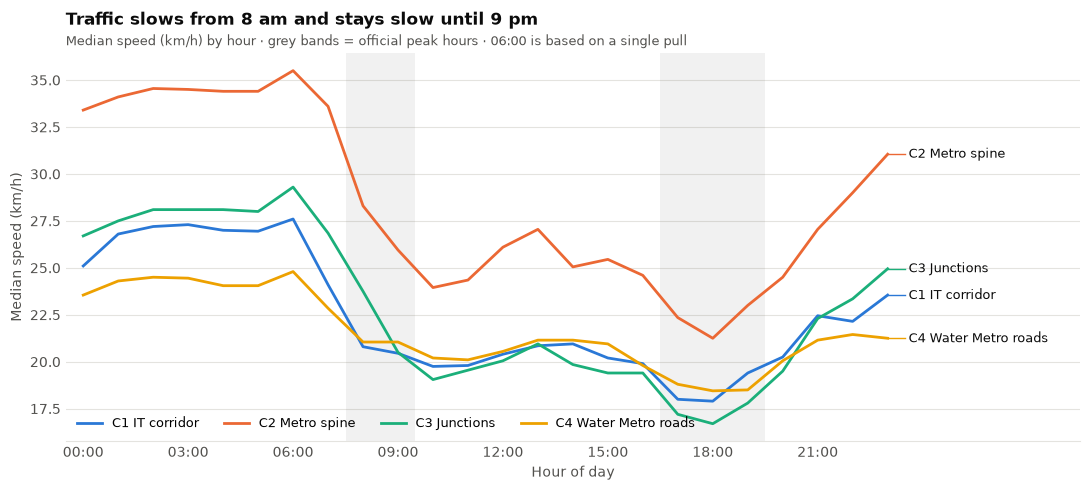

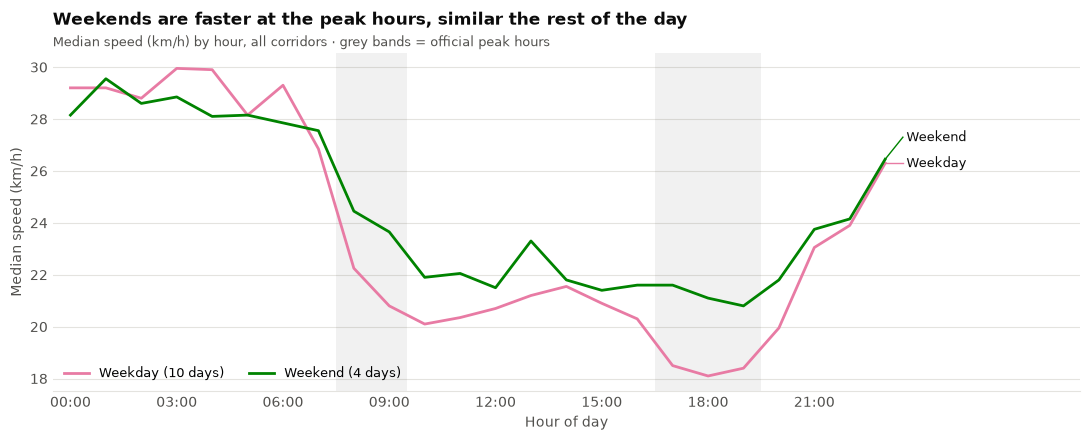


WEEKDAY vs WEEKEND (median km/h)
--------------------------------------------------------------------------------


is_weekend,Weekday,Weekend,Weekend faster by
period,,,
Night (00–06),29.3,28.4,-0.9
Early (07),26.8,27.6,0.8
Morning peak (08–09),21.4,24.2,2.8
Midday (10–16),20.9,21.8,0.9
Evening peak (17–19),18.4,21.0,2.6
Late evening (20–23),23.6,23.8,0.2


In [5]:
import matplotlib.pyplot as plt

# One fixed colour per corridor group (same colours in every later chart)
GROUP_COLORS = {"C1": "#2a78d6", "C2": "#eb6834", "C3": "#1baf7a", "C4": "#eda100"}
GROUP_LABELS = {"C1": "C1 IT corridor", "C2": "C2 Metro spine",
                "C3": "C3 Junctions", "C4": "C4 Water Metro roads"}
INK, MUTED, GRID = "#0b0b0b", "#52514e", "#e4e3df"
PEAK_HOURS = times.loc[times["is_peak_hour"], "hour_of_day"].tolist()


def style_axis(ax, title, subtitle):
    ax.set_title(f"{title}\n", loc="left", fontsize=12, color=INK, fontweight="bold")
    ax.text(0, 1.02, subtitle, transform=ax.transAxes, fontsize=9, color=MUTED)
    for side in ("top", "right", "left"):
        ax.spines[side].set_visible(False)
    ax.spines["bottom"].set_color(GRID)
    ax.grid(axis="y", color=GRID, linewidth=0.8)
    ax.set_axisbelow(True)
    ax.tick_params(colors=MUTED, length=0)
    ax.set_xticks(range(0, 24, 3), [f"{h:02d}:00" for h in range(0, 24, 3)])
    ax.set_xlabel("Hour of day", color=MUTED)
    for hour in PEAK_HOURS:
        ax.axvspan(hour - 0.5, hour + 0.5, color=MUTED, alpha=0.08, linewidth=0)


def label_line_ends(ax, series_by_label, colors, min_gap=1.0):
    """Direct-label each line at its right end, nudging labels apart so they don't overlap."""
    ends = sorted(((s.iloc[-1], label) for label, s in series_by_label.items()))
    placed = []
    for value, label in ends:
        y = max(value, placed[-1] + min_gap) if placed else value
        placed.append(y)
        ax.text(23.6, y, label, color=INK, fontsize=9, va="center")
        ax.plot([23, 23.5], [value, y], color=colors[label], linewidth=1)
    ax.set_xlim(-0.5, 28.5)


# --- 1. Readings per hour ----------------------------------------------
report("1. READINGS PER HOUR")
per_hour = df.groupby("hour_of_day").size()
print(f"Typical hour has {per_hour.median():.0f} readings (range {per_hour.min()}–{per_hour.max()})")
for hour, n in per_hour[per_hour < 50].items():
    print(f"Warning: {hour:02d}:00 has only {n} readings ({n // n_corridors} pull); treat it with caution")

# --- 2. Speed by time period -------------------------------------------
periods = {
    "Night (00–06)": range(0, 7),
    "Early (07)": [7],
    "Morning peak (08–09)": [8, 9],
    "Midday (10–16)": range(10, 17),
    "Evening peak (17–19)": [17, 18, 19],
    "Late evening (20–23)": range(20, 24),
}
hour_to_period = {h: name for name, hours in periods.items() for h in hours}
df["period"] = pd.Categorical(df["hour_of_day"].map(hour_to_period), categories=list(periods))

report("2. MEDIAN SPEED BY TIME PERIOD (km/h, and % slower than night)")
by_period = df.pivot_table(index="period", columns="corridor_group_id",
                           values="speed_kmh", aggfunc="median", observed=True)
by_period["All"] = df.groupby("period", observed=True)["speed_kmh"].median()
night = by_period.loc["Night (00–06)"]
slower = (1 - by_period / night) * 100
table = by_period.round(1).astype(str) + "  (" + slower.round(0).astype(int).astype(str) + "%)"
table.loc["Night (00–06)"] = by_period.loc["Night (00–06)"].round(1).astype(str) + "  (base)"
table.columns = [GROUP_LABELS.get(c, "All corridors") for c in table.columns]
display(table)

# --- 3. Chart: speed by hour per corridor group ------------------------
speed_by_hour = df.pivot_table(index="hour_of_day", columns="corridor_group_id",
                               values="speed_kmh", aggfunc="median")
fig, ax = plt.subplots(figsize=(11, 5))
lines = {}
for group, color in GROUP_COLORS.items():
    series = speed_by_hour[group]
    ax.plot(series.index, series.values, color=color, linewidth=2, label=GROUP_LABELS[group])
    lines[GROUP_LABELS[group]] = series
label_line_ends(ax, lines, {GROUP_LABELS[g]: c for g, c in GROUP_COLORS.items()})
style_axis(ax, "Traffic slows from 8 am and stays slow until 9 pm",
           "Median speed (km/h) by hour · grey bands = official peak hours · 06:00 is based on a single pull")
ax.set_ylabel("Median speed (km/h)", color=MUTED)
ax.legend(loc="lower left", frameon=False, fontsize=9, ncols=4)
plt.tight_layout()
plt.show()

# --- 4. Chart: weekday vs weekend --------------------------------------
day_type = df["is_weekend"].map({False: "Weekday", True: "Weekend"})
speed_by_day_type = df.pivot_table(index="hour_of_day", columns=day_type,
                                   values="speed_kmh", aggfunc="median")
day_colors = {"Weekday": "#e87ba4", "Weekend": "#008300"}
n_days = df.groupby(day_type)["date_key"].nunique()

fig, ax = plt.subplots(figsize=(11, 4.5))
for name, color in day_colors.items():
    series = speed_by_day_type[name].dropna()
    ax.plot(series.index, series.values, color=color, linewidth=2,
            label=f"{name} ({n_days[name]} days)")
label_line_ends(ax, {n: speed_by_day_type[n].dropna() for n in day_colors}, day_colors)
style_axis(ax, "Weekends are faster at the peak hours, similar the rest of the day",
           "Median speed (km/h) by hour, all corridors · grey bands = official peak hours")
ax.set_ylabel("Median speed (km/h)", color=MUTED)
ax.legend(loc="lower left", frameon=False, fontsize=9, ncols=2)
plt.tight_layout()
plt.show()

report("WEEKDAY vs WEEKEND (median km/h)")
compare = df.pivot_table(index="period", columns=day_type, values="speed_kmh",
                         aggfunc="median", observed=True).round(1)
compare["Weekend faster by"] = (compare["Weekend"] - compare["Weekday"]).round(1)
display(compare)

### Findings: Step 5

**Congestion lasts all day, not just at the peaks**
- At night (00–06) traffic flows at about **29 km/h**, which we treat as free-flow speed.
- Speed drops sharply from **8 am** and **stays low right through the day until about 9 pm**.
- **Midday (10–16) is as slow as the morning peak, or slower:** 21.1 km/h (27% slower than night) vs 22.1 km/h (24% slower) for 8–9 am.
- **The evening peak (5–7 pm) is the worst time of day:** 19.3 km/h, **33% slower than night**. The slowest single hour is 6 pm.
- Traffic recovers after 9 pm but is still 18% slower than night until midnight.

**The official peak hours are only half right.** `dim_time` marks 8–9 am and 5–7 pm as peak. The evening peak is real, but there is **no distinct morning peak**: the whole 8 am – 5 pm stretch is congested. For planning, "peak" should mean **roughly 8 am – 8 pm, worst 5–7 pm**.

**By corridor group** (evening peak vs night)

| Group | Night | Evening peak | Slower by |
|---|---|---|---|
| C3 Junctions | 27.9 km/h | 17.4 km/h | **38%**, the biggest drop |
| C2 Metro spine | 34.4 km/h | 22.4 km/h | 35% |
| C1 IT corridor | 27.0 km/h | 18.4 km/h | 32% |
| C4 Water Metro roads | 24.1 km/h | 18.7 km/h | 22%, the smallest drop |

- **C2, the metro spine, loses the most absolute speed** (34 → 22 km/h). This is the corridor the Metro runs along, so it's where the Metro has the most to offer at peak times.
- **C4 changes least over the day but is slow all the time** (24 km/h even at night). That points to the route itself (distance, junctions, road layout) rather than rush-hour traffic. So the road is slow for anyone at any hour, which strengthens the case for the Water Metro on Vyttila ↔ Kakkanad.

**Weekday vs weekend**
- Weekends are faster at the peaks: **+2.8 km/h in the morning, +2.6 km/h in the evening.**
- At night, midday and late evening they are about the same.
- So **the peaks are commuter-driven**, while midday congestion happens every day.
- Caution: there are only 4 weekend days vs 10 weekdays.

**Data caveat:** 06:00 has only 18 readings, from a single pull, so its value is unreliable. Every other hour has 144–342 readings.

## Step 6: Does rain slow traffic?

The project's core question. Comparing rainy and dry readings directly would be misleading, because traffic depends heavily on the **time of day** (Step 5) and on the **corridor**. So every reading is compared with what's normal for that corridor at that hour:

> **Speed vs normal** = the reading's speed ÷ the median speed for that corridor at that hour of day.
> 1.00 = normal, 1.10 = 10% faster than usual, 0.90 = 10% slower.

1. **How much it rained:** rain hours by intensity during the traffic period (17–30 Aug)
2. **Simple comparison:** speed vs normal for dry, drizzle, light and moderate/heavy rain
3. **Chart: day by day.** Daily rainfall next to daytime speed, to check whether particular days drive the result
4. **Fair comparison:** rainy vs dry hours **on the same day and the same corridor**, which removes day-to-day differences such as holidays

Rain intensity classes (mm per hour): **dry** 0 · **drizzle** up to 0.5 · **light** 0.5–2.5 · **moderate/heavy** over 2.5.


1. RAIN DURING THE TRAFFIC PERIOD (17–30 Aug)
--------------------------------------------------------------------------------
Dry               157 hours  (47%)
Drizzle           108 hours  (32%)
Light              55 hours  (16%)
Moderate/heavy     16 hours  (5%)
Heaviest hour: 11.4 mm

2. SIMPLE COMPARISON: speed vs normal, by rain intensity
--------------------------------------------------------------------------------
Dry              1,901 readings   all hours   -0.5%   daytime (08–20)   -1.7%
Drizzle          1,656 readings   all hours   +0.0%   daytime (08–20)   +1.2%
Light              918 readings   all hours   +0.3%   daytime (08–20)   +2.6%
Moderate/heavy     252 readings   all hours   +5.7%   daytime (08–20)  +13.9%

Taken at face value, rain makes traffic FASTER, and heavier rain even more so.
That is suspicious; section 3 checks whether particular days explain it.

3. DAILY: total rain and daytime speed vs normal (days with full daytime coverage)
----------------------

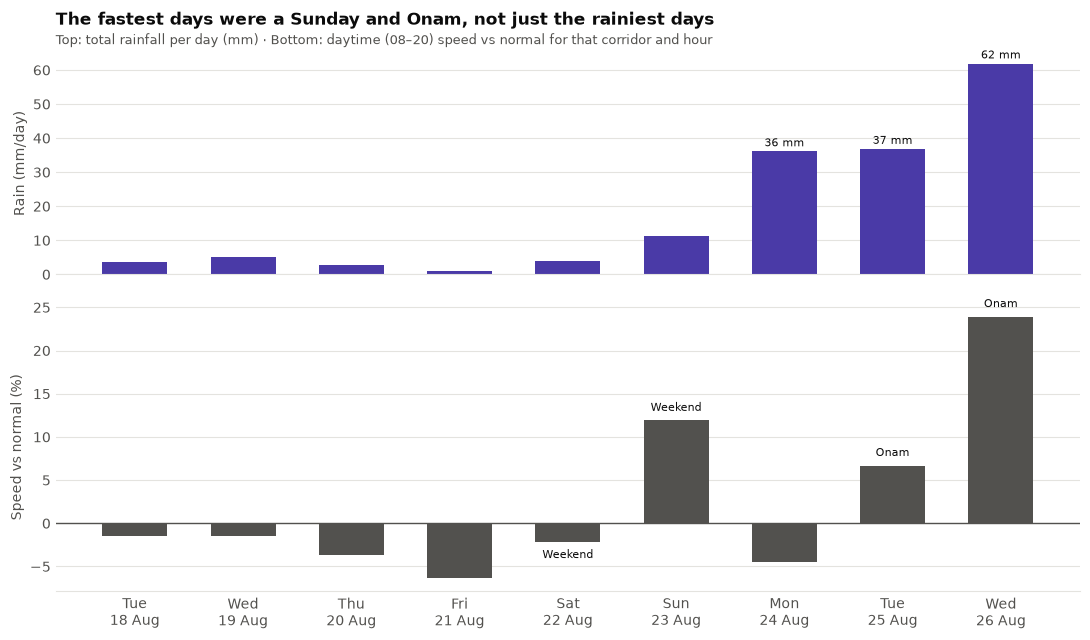


4. FAIR COMPARISON: rainy vs dry daytime hours on the SAME day and corridor (all days)
--------------------------------------------------------------------------------
Day + corridor combinations with both rainy and dry hours: 144 (across 8 days)
Median effect of rain on speed : +1.6%
Rain was slower in             : 42% of comparisons
Middle 50% of effects          : -2.6% to +5.9%

5. ORDINARY WORKING DAYS ONLY (no weekends, no holidays, full-coverage days)
--------------------------------------------------------------------------------
Days: Tue 18 Aug, Wed 19 Aug, Thu 20 Aug, Fri 21 Aug, Mon 24 Aug

Dry                684 readings   speed vs normal   +0.0%
Drizzle            360 readings   speed vs normal   +0.0%
Light              126 readings   speed vs normal   +0.5%
Moderate/heavy      18 readings   speed vs normal   -0.8%

Day + corridor combinations with both rainy and dry hours: 72 (across 4 days)
Median effect of rain on speed : -0.0%
Rain was slower in             : 50% o

In [7]:
RAIN_CLASSES = ["Dry", "Drizzle", "Light", "Moderate/heavy"]
RAIN_BINS = [-0.01, 0, 0.5, 2.5, float("inf")]
RAIN_COLOR, SPEED_COLOR = "#4a3aa7", "#52514e"
DAYTIME = range(8, 21)  # the congested hours found in Step 5
# Onam 2026: Uthradam (25 Aug) and Thiruvonam (26 Aug), public holidays in Kerala
HOLIDAYS = pd.to_datetime(["2026-08-25", "2026-08-26"])

# Speed vs normal: each reading ÷ the median speed for that corridor at that hour
normal_speed = df.groupby(["corridor_id", "hour_of_day"])["speed_kmh"].transform("median")
df["speed_vs_normal"] = df["speed_kmh"] / normal_speed
df["rain_class"] = pd.cut(df["precipitation_mm"], RAIN_BINS, labels=RAIN_CLASSES)
daytime = df[df["hour_of_day"].isin(DAYTIME)]


def pct(ratio):
    """1.07 -> '+7.0%'"""
    return f"{(ratio - 1) * 100:+.1f}%"


def rain_vs_dry_same_day(readings):
    """Compare rainy vs dry hours within each (day, corridor), which cancels out day-level effects."""
    pairs = (
        readings.groupby(["date_key", "corridor_id", "is_raining"])["speed_vs_normal"]
        .median()
        .unstack()
        .dropna()
    )
    effect = pairs[True] / pairs[False]
    n_days = pairs.index.get_level_values("date_key").nunique()
    print(f"Day + corridor combinations with both rainy and dry hours: {len(pairs)} (across {n_days} days)")
    print(f"Median effect of rain on speed : {pct(effect.median())}")
    print(f"Rain was slower in             : {(effect < 1).mean():.0%} of comparisons")
    print(f"Middle 50% of effects          : {pct(effect.quantile(0.25))} to {pct(effect.quantile(0.75))}")


# --- 1. How much it rained ---------------------------------------------
report("1. RAIN DURING THE TRAFFIC PERIOD (17–30 Aug)")
traffic_weather = weather[weather["date_key"].between(travel["date_key"].min(),
                                                      travel["date_key"].max())].copy()
traffic_weather["rain_class"] = pd.cut(traffic_weather["precipitation_mm"], RAIN_BINS,
                                       labels=RAIN_CLASSES)
rain_hours = traffic_weather["rain_class"].value_counts().reindex(RAIN_CLASSES)
for rain_class, hours in rain_hours.items():
    print(f"{rain_class:<16} {hours:>4} hours  ({hours / len(traffic_weather):.0%})")
print(f"Heaviest hour: {traffic_weather['precipitation_mm'].max()} mm")

# --- 2. Simple comparison ----------------------------------------------
report("2. SIMPLE COMPARISON: speed vs normal, by rain intensity")
simple = pd.DataFrame({
    "readings": df.groupby("rain_class", observed=True).size(),
    "all_hours": df.groupby("rain_class", observed=True)["speed_vs_normal"].median(),
    "daytime": daytime.groupby("rain_class", observed=True)["speed_vs_normal"].median(),
})
for rain_class, row in simple.iterrows():
    print(f"{rain_class:<16} {row['readings']:>5,.0f} readings   all hours {pct(row['all_hours']):>7}"
          f"   daytime (08–20) {pct(row['daytime']):>7}")
print("\nTaken at face value, rain makes traffic FASTER, and heavier rain even more so.")
print("That is suspicious; section 3 checks whether particular days explain it.")

# --- 3. Chart: day by day ----------------------------------------------
daily = daytime.groupby("date_key").agg(
    speed_vs_normal=("speed_vs_normal", "median"),
    readings=("speed_vs_normal", "size"),
    is_weekend=("is_weekend", "first"),
)
daily["rain_mm"] = weather.groupby("date_key")["precipitation_mm"].sum().reindex(daily.index)
# Only days with full daytime coverage: collection started on the night of 17 Aug, and
# ingestion problems cut it to 3–6 pulls a day from 27 Aug, so those days can't give a reliable daily figure
daily = daily[daily["readings"] >= 100]

report("3. DAILY: total rain and daytime speed vs normal (days with full daytime coverage)")
for date, row in daily.iterrows():
    note = "  holiday (Onam)" if date in HOLIDAYS else ("  weekend" if row["is_weekend"] else "")
    print(f"{date:%a %d %b}   rain {row['rain_mm']:>5.1f} mm   speed {pct(row['speed_vs_normal']):>7}{note}")

positions = range(len(daily))
speed_pct = (daily["speed_vs_normal"] - 1) * 100
fig, (ax_rain, ax_speed) = plt.subplots(2, 1, figsize=(11, 6.5), sharex=True,
                                        gridspec_kw={"height_ratios": [1, 1.3]})
ax_rain.bar(positions, daily["rain_mm"], color=RAIN_COLOR, width=0.6)
for i, mm in zip(positions, daily["rain_mm"]):
    if mm > 20:
        ax_rain.text(i, mm + 1.5, f"{mm:.0f} mm", ha="center", fontsize=8, color=INK)
ax_rain.set_title("The fastest days were a Sunday and Onam, not just the rainiest days\n", loc="left",
                  fontsize=12, color=INK, fontweight="bold")
ax_rain.text(0, 1.04, "Top: total rainfall per day (mm) · Bottom: daytime (08–20) speed vs normal "
             "for that corridor and hour", transform=ax_rain.transAxes, fontsize=9, color=MUTED)
ax_rain.set_ylabel("Rain (mm/day)", color=MUTED)

ax_speed.axhline(0, color=MUTED, linewidth=1)
ax_speed.bar(positions, speed_pct, color=SPEED_COLOR, width=0.6)
for i, (date, value) in enumerate(speed_pct.items()):
    if date in HOLIDAYS or daily.loc[date, "is_weekend"]:
        tag = "Onam" if date in HOLIDAYS else "Weekend"
        ax_speed.text(i, value + (0.8 if value >= 0 else -0.8), tag, ha="center",
                      va="bottom" if value >= 0 else "top", fontsize=8, color=INK)
ax_speed.set_ylabel("Speed vs normal (%)", color=MUTED)
ax_speed.set_xticks(list(positions), [f"{d:%a}\n{d:%d %b}" for d in daily.index])

for ax in (ax_rain, ax_speed):
    for side in ("top", "right", "left"):
        ax.spines[side].set_visible(False)
    ax.spines["bottom"].set_color(GRID)
    ax.grid(axis="y", color=GRID, linewidth=0.8)
    ax.set_axisbelow(True)
    ax.tick_params(colors=MUTED, length=0)
plt.tight_layout()
plt.show()

# --- 4. Fair comparison: same day, same corridor -----------------------
report("4. FAIR COMPARISON: rainy vs dry daytime hours on the SAME day and corridor (all days)")
rain_vs_dry_same_day(daytime)

# --- 5. Ordinary working days only -------------------------------------
working = daytime[
    daytime["date_key"].isin(daily.index)
    & ~daytime["is_weekend"]
    & ~daytime["date_key"].isin(HOLIDAYS)
].copy()
# Re-measure "normal" using working days only, so holidays don't set the baseline
working["speed_vs_normal"] = working["speed_kmh"] / working.groupby(
    ["corridor_id", "hour_of_day"])["speed_kmh"].transform("median")

report("5. ORDINARY WORKING DAYS ONLY (no weekends, no holidays, full-coverage days)")
print("Days: " + ", ".join(f"{d:%a %d %b}" for d in sorted(working["date_key"].unique())))
print()
by_class = working.groupby("rain_class", observed=True)["speed_vs_normal"].agg(["median", "size"])
for rain_class, row in by_class.iterrows():
    print(f"{rain_class:<16} {row['size']:>5,.0f} readings   speed vs normal {pct(row['median']):>7}")
print()
rain_vs_dry_same_day(working)

### Findings: Step 6

**Headline: this data shows no measurable effect of rain on traffic speed.** The apparent "rain makes traffic faster" result is caused by holidays, not by rain.

**1. How much it rained (17–30 Aug)**
- 53% of hours had some rain, but most of it was light:
  - drizzle ≤ 0.5 mm/h: 32% of hours
  - light 0.5–2.5 mm/h: 16%
  - moderate/heavy > 2.5 mm/h: 5%, only **16 hours**
- The heaviest single hour had 11.4 mm.

**2. The simple comparison is misleading.** Compared with normal for the same corridor and hour, daytime speeds were:
- dry: 1.7% *below* normal
- moderate/heavy rain: **13.9% *above* normal**

Taken at face value, heavier rain means faster traffic.

**3. Day by day, the cause becomes clear.** The wettest days were 24–26 Aug. Two of those three days were **Onam holidays** (Tue 25 = Uthradam, Wed 26 = Thiruvonam), when fewer people travel:

| Day | Rain (whole day) | Daytime speed vs normal |
|---|---|---|
| Sun 23 Aug (weekend) | 11 mm | +11.9% |
| **Mon 24 Aug (working day)** | **36 mm** | **−4.5%**, a very wet day, yet slightly *slower* |
| Tue 25 Aug (Onam) | 37 mm | +6.7% |
| Wed 26 Aug (Onam) | 62 mm | **+23.9%**, the fastest day in the data |

Traffic was fast on those days because fewer people were travelling, and it happened to be raining.

**4. Fair comparison (rainy vs dry hours on the same day and corridor)**
- Rain effect: **+1.6%** (median), and rain was slower in only 42% of comparisons.
- That is essentially no effect, well within normal hour-to-hour variation (middle 50%: −2.6% to +5.9%).

**5. Ordinary working days only** (18–21 and 24 Aug)
- Every rain class is within **±1% of normal**.
- Same-day comparison: **−0.0%**, with rain slower in exactly 50% of comparisons.

**What this means for the project**
- **We can't conclude that rain doesn't matter.** We can only say this data can't show an effect. On working days there was only **1 daytime hour** of moderate/heavy rain (18 readings), too little to measure a heavy-rain effect. Most of Monday 24 Aug's 36 mm fell outside 08–20. Drizzle and light rain, which make up most monsoon rain, appear to make no difference.
- **Holidays have a bigger effect on traffic than rain** in this data. `dim_date` needs an **`is_holiday`** flag, or holiday effects will keep being mistaken for weather effects.
- **To answer the rain question properly we need more data:** several weeks of collection that include heavy daytime rain on ordinary working days.

**⚠️ Data collection issue found here:** traffic pulls dropped from **22–33 a day (18–26 Aug) to only 3–6 a day (27–30 Aug)**. Effectively **only 18–26 Aug has full coverage.** Confirmed: the ingestion job had problems during this period. **Any analysis that needs whole days should use 18–26 Aug only.**

## Step 7: Road vs Metro

For each corridor, is the Kochi Metro faster than driving, and at what times of day?

**Data:** the GTFS timetable in the `raw` tables. It covers **Kochi Metro only**: one line, 25 stations from Aluva to Tripunithura. It has no Water Metro schedule, so the C4 Water Metro comparison isn't possible yet.

1. **Coverage:** which corridors start and end near a metro station
2. **Timetable:** how long ago it was valid, and trains per hour on weekdays
3. **Comparison:** road travel time vs metro time (average wait + ride), per corridor
4. **Chart:** road vs metro through the day for each corridor

How the comparison works:
- **Metro time** = average wait for the next train (half the gap between trains) + time on the train, from the weekday timetable.
- **Road time** = median TomTom travel time on **ordinary working days only** (no weekends, no Onam, full-coverage days; see Step 6).
- **Walking to and from the stations is not included.** The walk distances are shown in section 1. A metro advantage of under about 5 minutes is likely cancelled out by walking.


1. WHICH CORRIDORS HAVE A METRO ALTERNATIVE?
--------------------------------------------------------------------------------


,Corridor,Route,Metro alternative,Board at,Walk to station (km),Alight at,Walk from station (km)
0,C2_4_fwd,Aluva Metro Station → MG Road Metro Station,Yes,Aluva,0.3,MG Road,0.4
1,C2_4_rev,MG Road Metro Station → Aluva Metro Station,Yes,MG Road,0.4,Aluva,0.3
2,C2_5_fwd,Edappally Junction → Vyttila Mobility Hub,Yes,Edapally,0.4,Vyttila,0.2
3,C2_5_rev,Vyttila Mobility Hub → Edappally Junction,Yes,Vyttila,0.2,Edapally,0.4
4,C2_6_fwd,Kaloor Junction → Tripunithura Metro Station,Yes,JLN Stadium,0.3,Tripunithura,1.3
5,C2_6_rev,Tripunithura Metro Station → Kaloor Junction,Yes,Tripunithura,1.3,JLN Stadium,0.3
6,C3_7_fwd,Edappally Junction → Palarivattom Junction,Yes,Edapally,0.4,Palarivattom,1.1
7,C3_7_rev,Palarivattom Junction → Edappally Junction,Yes,Palarivattom,1.1,Edapally,0.4
8,C3_8_fwd,Palarivattom Junction → Vyttila Mobility Hub,Yes,Palarivattom,1.1,Vyttila,0.2
9,C3_8_rev,Vyttila Mobility Hub → Palarivattom Junction,Yes,Vyttila,0.2,Palarivattom,1.1


10 of 18 corridors have a metro alternative. In the other 8 (C1 IT corridor, C4 Kakkanad), one end is 4.3–6.5 km from the nearest station.

2. METRO TIMETABLE (GTFS)
--------------------------------------------------------------------------------
Service WK: Mon–Sat, valid 12 Aug 2024 to 31 Dec 2025
Service WE: Sun, valid 12 Aug 2024 to 31 Dec 2025
Note: the traffic data is from Aug 2026, after this timetable's end date; the real 2026 schedule may differ.

Weekday service (trains per hour, one direction): first hour 05:00, last hour 22:00
  05h:2  06h:3  07h:8  08h:8  09h:9  10h:7  11h:7  12h:7  13h:7  14h:7  15h:8  16h:8  17h:9  18h:9  19h:7  20h:6  21h:4  22h:4

3. ROAD vs METRO, daytime 08–20 on ordinary working days (positive = metro saves time)
--------------------------------------------------------------------------------


,Corridor,Trip,"Road, typical (min)","Road, worst hour (min)",Worst hour,Metro wait + ride (min),"Metro saves, typical (min)","Metro saves, worst hour (min)",Verdict
0,C2_4_rev,MG Road → Aluva,46.2,53.4,18:00,32.3,14.0,21.1,Metro faster
1,C2_4_fwd,Aluva → MG Road,45.3,49.2,10:00,32.7,12.6,16.5,Metro faster
2,C3_7_fwd,Edapally → Palarivattom,11.2,11.9,18:00,8.0,3.2,4.8,About equal; walking decides
3,C3_7_rev,Palarivattom → Edapally,10.5,12.0,20:00,7.9,2.6,4.1,About equal; walking decides
4,C2_6_rev,Tripunithura → JLN Stadium,30.0,34.7,11:00,31.0,-1.0,3.6,About equal; walking decides
5,C2_6_fwd,JLN Stadium → Tripunithura,29.8,35.3,18:00,31.1,-1.3,4.6,About equal; walking decides
6,C2_5_rev,Vyttila → Edapally,20.2,23.1,18:00,26.5,-6.3,-3.4,Road faster
7,C2_5_fwd,Edapally → Vyttila,18.4,22.8,18:00,26.9,-8.5,-3.3,Road faster
8,C3_8_rev,Vyttila → Palarivattom,13.8,16.1,18:00,22.4,-8.6,-6.4,Road faster
9,C3_8_fwd,Palarivattom → Vyttila,12.8,16.0,18:00,22.5,-9.6,-6.1,Road faster


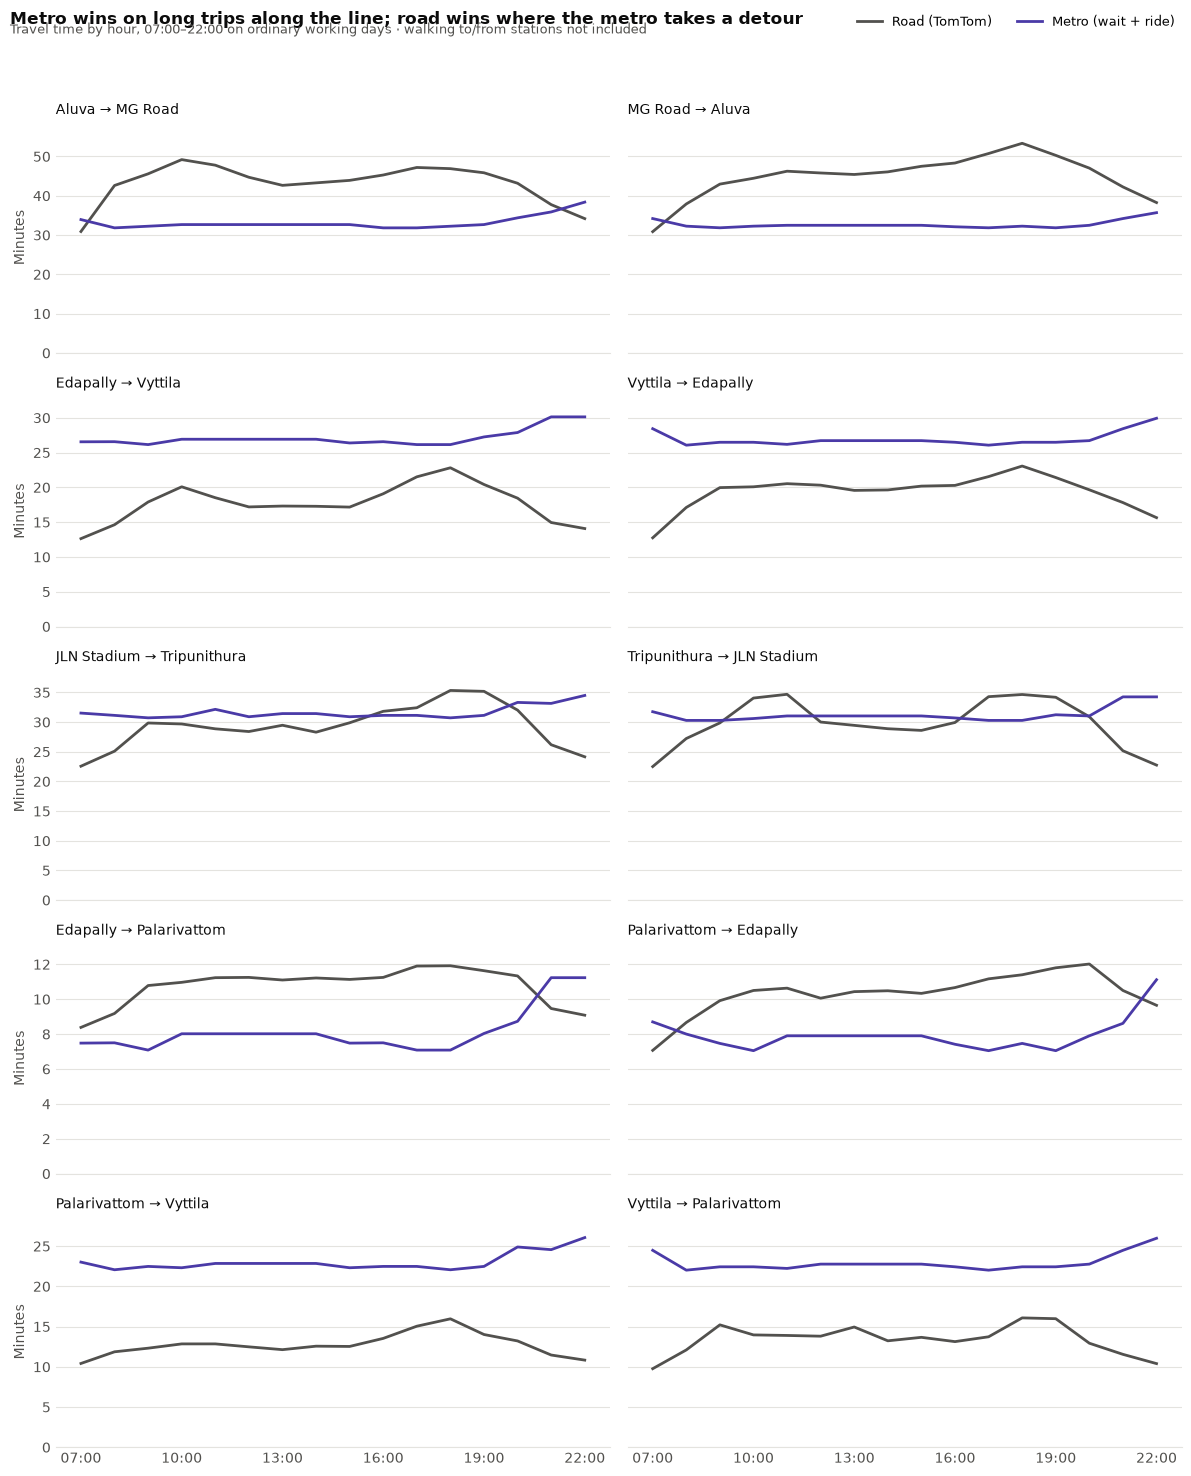

In [9]:
import numpy as np

RAW_DIR = Path("../data/exports/raw")
stops = pd.read_csv(RAW_DIR / "gtfs_stops.csv")
stop_times = pd.read_csv(RAW_DIR / "gtfs_stop_times.csv")
gtfs_trips = pd.read_csv(RAW_DIR / "gtfs_trips.csv")
calendar = pd.read_csv(RAW_DIR / "gtfs_calendar.csv", dtype={"start_date": str, "end_date": str})

ROAD_COLOR, METRO_COLOR = "#52514e", "#4a3aa7"
WEEKDAY_SERVICE = "WK"  # GTFS service_id that runs Monday–Saturday
WORKING_DAYS = working["date_key"].unique()  # ordinary working days from Step 6

# Station pairs for corridors whose ends are at or near a metro station (forward direction;
# the reverse corridor uses the same pair the other way round)
METRO_PAIRS = {
    "C2_4": ("ALVA", "MGRD"),  # Aluva → MG Road
    "C2_5": ("EDAP", "VYTA"),  # Edappally → Vyttila
    "C2_6": ("JLSD", "TPHT"),  # Kaloor Junction (nearest station: JLN Stadium) → Tripunithura
    "C3_7": ("EDAP", "PARV"),  # Edappally → Palarivattom
    "C3_8": ("PARV", "VYTA"),  # Palarivattom → Vyttila
}
station = stops.set_index("stop_id")


def distance_m(lat1, lon1, lat2, lon2):
    """Straight-line distance in metres (haversine formula)."""
    lat1, lon1, lat2, lon2 = map(np.radians, (lat1, lon1, lat2, lon2))
    a = np.sin((lat2 - lat1) / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin((lon2 - lon1) / 2) ** 2
    return 2 * 6_371_000 * np.arcsin(np.sqrt(a))


def nearest_station(lat, lon):
    distances = distance_m(lat, lon, stops["stop_lat"].to_numpy(), stops["stop_lon"].to_numpy())
    return stops["stop_id"].iloc[distances.argmin()]


def stations_for(corridor_id):
    """(boarding, alighting) station ids, or None if the corridor has no metro alternative."""
    base, direction = corridor_id.rsplit("_", 1)
    if base not in METRO_PAIRS:
        return None
    a, b = METRO_PAIRS[base]
    return (a, b) if direction == "fwd" else (b, a)


def walk_m(lat, lon, stop_id):
    return distance_m(lat, lon, station.loc[stop_id, "stop_lat"], station.loc[stop_id, "stop_lon"])


# --- 1. Coverage -------------------------------------------------------
report("1. WHICH CORRIDORS HAVE A METRO ALTERNATIVE?")
coverage = []
for c in corridors.itertuples():
    pair = stations_for(c.corridor_id)
    board, alight = pair or (nearest_station(c.origin_lat, c.origin_lon),
                             nearest_station(c.destination_lat, c.destination_lon))
    coverage.append({
        "Corridor": c.corridor_id,
        "Route": f"{c.origin_name} → {c.destination_name}",
        "Metro alternative": "Yes" if pair else "No",
        "Board at": station.loc[board, "stop_name"],
        "Walk to station (km)": walk_m(c.origin_lat, c.origin_lon, board) / 1000,
        "Alight at": station.loc[alight, "stop_name"],
        "Walk from station (km)": walk_m(c.destination_lat, c.destination_lon, alight) / 1000,
    })
coverage = pd.DataFrame(coverage).sort_values(["Metro alternative", "Corridor"], ascending=[False, True])
display(coverage.round(1).reset_index(drop=True))
n_served = (coverage["Metro alternative"] == "Yes").sum()
unserved = coverage[coverage["Metro alternative"] == "No"]
farther_end_km = unserved[["Walk to station (km)", "Walk from station (km)"]].max(axis=1)
print(f"{n_served} of {len(coverage)} corridors have a metro alternative. In the other {len(unserved)} "
      f"(C1 IT corridor, C4 Kakkanad), one end is {farther_end_km.min():.1f}–{farther_end_km.max():.1f} km "
      f"from the nearest station.")

# --- 2. Timetable ------------------------------------------------------
report("2. METRO TIMETABLE (GTFS)")
for s in calendar.itertuples():
    days = [d[:3].title() for d in ["monday", "tuesday", "wednesday", "thursday", "friday",
                                     "saturday", "sunday"] if getattr(s, d) == 1]
    print(f"Service {s.service_id}: {'–'.join([days[0], days[-1]]) if len(days) > 1 else days[0]}, "
          f"valid {pd.to_datetime(s.start_date):%d %b %Y} to {pd.to_datetime(s.end_date):%d %b %Y}")
print("Note: the traffic data is from Aug 2026, after this timetable's end date; "
      "the real 2026 schedule may differ.")

stop_times["arrival_s"] = pd.to_timedelta(stop_times["arrival_time"]).dt.total_seconds()
stop_times["departure_s"] = pd.to_timedelta(stop_times["departure_time"]).dt.total_seconds()
weekday_times = stop_times.merge(gtfs_trips[["trip_id", "service_id"]], on="trip_id")
weekday_times = weekday_times[weekday_times["service_id"] == WEEKDAY_SERVICE]


def metro_by_hour(board, alight):
    """Per departure hour: trains, ride time, and average wait (half the gap between trains)."""
    dep = weekday_times[weekday_times["stop_id"] == board][["trip_id", "stop_sequence", "departure_s"]]
    arr = weekday_times[weekday_times["stop_id"] == alight][["trip_id", "stop_sequence", "arrival_s"]]
    legs = dep.merge(arr, on="trip_id", suffixes=("_board", "_alight"))
    legs = legs[legs["stop_sequence_alight"] > legs["stop_sequence_board"]]  # right direction only
    legs["ride_min"] = (legs["arrival_s"] - legs["departure_s"]) / 60
    legs["hour"] = (legs["departure_s"] // 3600).astype(int)
    by_hour = legs.groupby("hour").agg(trains=("ride_min", "size"), ride_min=("ride_min", "median"))
    by_hour["wait_min"] = 60 / by_hour["trains"] / 2
    by_hour["metro_min"] = by_hour["ride_min"] + by_hour["wait_min"]
    return by_hour


frequency = metro_by_hour("EDAP", "VYTA")["trains"]
print(f"\nWeekday service (trains per hour, one direction): first hour {frequency.index.min():02d}:00, "
      f"last hour {frequency.index.max():02d}:00")
print("  " + "  ".join(f"{h:02d}h:{n}" for h, n in frequency.items()))

# --- 3. Road vs metro --------------------------------------------------
road_by_hour = (
    df[df["date_key"].isin(WORKING_DAYS)]
    .groupby(["corridor_id", "hour_of_day"])["travel_time_min"]
    .median()
)

hourly = {}
summary = []
for corridor_id in coverage.loc[coverage["Metro alternative"] == "Yes", "Corridor"]:
    board, alight = stations_for(corridor_id)
    h = metro_by_hour(board, alight)
    h["road_min"] = road_by_hour.loc[corridor_id]
    h = h.dropna()
    hourly[corridor_id] = h
    day = h.loc[h.index.isin(DAYTIME)]
    worst_hour = day["road_min"].idxmax()
    saving_typical = day["road_min"].median() - day["metro_min"].median()
    summary.append({
        "Corridor": corridor_id,
        "Trip": f"{station.loc[board, 'stop_name']} → {station.loc[alight, 'stop_name']}",
        "Road, typical (min)": day["road_min"].median(),
        "Road, worst hour (min)": day["road_min"].max(),
        "Worst hour": f"{worst_hour:02d}:00",
        "Metro wait + ride (min)": day["metro_min"].median(),
        "Metro saves, typical (min)": saving_typical,
        "Metro saves, worst hour (min)": day["road_min"].max() - h.loc[worst_hour, "metro_min"],
        "Verdict": ("Metro faster" if saving_typical > 5
                    else "Road faster" if saving_typical < -5
                    else "About equal; walking decides"),
    })

report("3. ROAD vs METRO, daytime 08–20 on ordinary working days (positive = metro saves time)")
summary = pd.DataFrame(summary).sort_values("Metro saves, typical (min)", ascending=False)
display(summary.round(1).reset_index(drop=True))

# --- 4. Chart ----------------------------------------------------------
CHART_HOURS = range(7, 23)  # before 07:00 and after 22:00 trains are too sparse to compare
pairs_in_order = list(METRO_PAIRS)
fig, axes = plt.subplots(len(pairs_in_order), 2, figsize=(12, 3 * len(pairs_in_order)),
                         sharex=True, sharey="row")
for row, base in enumerate(pairs_in_order):
    for col, direction in enumerate(["fwd", "rev"]):
        ax = axes[row, col]
        corridor_id = f"{base}_{direction}"
        h = hourly[corridor_id].loc[lambda t: t.index.isin(CHART_HOURS)]
        board, alight = stations_for(corridor_id)
        ax.plot(h.index, h["road_min"], color=ROAD_COLOR, linewidth=2, label="Road (TomTom)")
        ax.plot(h.index, h["metro_min"], color=METRO_COLOR, linewidth=2, label="Metro (wait + ride)")
        ax.set_title(f"{station.loc[board, 'stop_name']} → {station.loc[alight, 'stop_name']}",
                     loc="left", fontsize=10, color=INK)
        for side in ("top", "right", "left"):
            ax.spines[side].set_visible(False)
        ax.spines["bottom"].set_color(GRID)
        ax.grid(axis="y", color=GRID, linewidth=0.8)
        ax.set_axisbelow(True)
        ax.tick_params(colors=MUTED, length=0)
        if col == 0:
            ax.set_ylabel("Minutes", color=MUTED)
    # Set the shared y-range once both directions are drawn, so neither panel is clipped
    row_max = max(hourly[f"{base}_{d}"].loc[lambda t: t.index.isin(CHART_HOURS),
                                            ["road_min", "metro_min"]].to_numpy().max()
                  for d in ("fwd", "rev"))
    axes[row, 0].set_ylim(0, row_max * 1.1)
for ax in axes[-1]:
    ax.set_xticks(range(7, 23, 3), [f"{h:02d}:00" for h in range(7, 23, 3)])
fig.suptitle("Metro wins on long trips along the line; road wins where the metro takes a detour",
             x=0.01, ha="left", fontsize=12, fontweight="bold", color=INK)
fig.text(0.01, 0.965, "Travel time by hour, 07:00–22:00 on ordinary working days · walking to/from stations not included",
         fontsize=9, color=MUTED)
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right", bbox_to_anchor=(0.99, 0.985), frameon=False,
           ncols=2, fontsize=9)
plt.tight_layout(rect=(0, 0, 1, 0.95))
plt.show()

### Findings: Step 7

**Coverage: the slowest part of the city has no metro**
- **10 of 18 corridors have a metro alternative:** all of C2 (metro spine) and C3 (junctions).
- **The other 8, all of C1 IT corridor and C4 Kakkanad, have one end 4.3–6.5 km from the nearest station.** These are the **slowest corridors in the data** (about 22 km/h, Step 4). Infopark, SmartCity and Kakkanad aren't on the current metro line.

**Road vs metro** (daytime 08–20, ordinary working days)

| Trip | Road, typical | Metro, wait + ride | Result |
|---|---|---|---|
| **Aluva ↔ MG Road** | 45–46 min (up to 53 at 6 pm) | **32–33 min** | **Metro saves 13–14 min, up to 21 min at 6 pm** |
| Edappally ↔ Palarivattom | 10.5–11 min | 8 min | Metro saves about 3 min; walking cancels it out |
| Kaloor (JLN Stadium) ↔ Tripunithura | 30 min (35 at peak) | 31 min | About equal: road wins midday, metro wins 5–7 pm |
| Edappally ↔ Vyttila | 18–20 min | 27 min | **Road faster by 6–9 min** |
| Palarivattom ↔ Vyttila | 13–14 min | 22–23 min | **Road faster by 9–10 min** |

- **The metro wins clearly on long north–south trips** like Aluva ↔ city centre. It's faster at every hour from 8 am to 8 pm, with short walks at both ends (0.3–0.4 km).
- **The road wins for trips to and from Vyttila from the north.** The metro line goes through the city centre (Kaloor, MG Road, Kadavanthra), while the road takes the direct bypass. For Edappally → Vyttila, that means 11 stations and 23 minutes on the train for a 7.6 km drive.
- **The metro is predictable.** Its time stays within about 1 minute from 8 am to 7 pm. Road times swing by 5–10 minutes over the day, and worst-case trips take 1.4–1.6× the typical time (Step 4).
- **Frequency:** trains run every 7–8.5 minutes in the daytime (7–9 per hour). Service thins after 8 pm, and by 10 pm (every 15 minutes) the road is faster on every corridor.

**What this means for transit planning**
1. **The biggest gap is Kakkanad / Infopark.** It's the slowest area, with no metro and no road alternative. A metro extension towards Infopark would serve exactly the corridors that most need it.
2. **Vyttila ↔ Edappally/Palarivattom trips need a direct link.** Riding the metro here is slower than driving, so a direct feeder bus along the bypass would suit these trips better.
3. **The C4 Water Metro comparison still needs data.** The GTFS feed has no Water Metro schedule, so we need its timetable (Vyttila ↔ Kakkanad).

**Caveats**
- **The timetable is out of date.** It is valid Aug 2024 – Dec 2025, but the traffic data is from Aug 2026, and the real schedule may have changed.
- **Walking to and from stations is not included.** Most walks are 0.2–0.4 km, but the GTFS coordinates put **Palarivattom station 1.1 km** and **Tripunithura station 1.3 km** from the corridor end points. That's worth checking against `dim_corridor`: if the corridor coordinates are wrong, the road data for those corridors is measuring slightly different trips.
- **The metro time is the average case.** It assumes you arrive at the station at a random time, so the average wait is half the gap between trains.

## Step 8: Summary and route map

The final step brings everything together:

1. **Route map:** the actual road route each corridor follows (the route TomTom used most often), coloured by corridor group, with the Kochi Metro line on top. Hover over a route for its typical travel time, speed and metro verdict. Use the layer control (top right) to switch groups on and off.
2. **Summary of findings:** the key results from Steps 1–7 in one place, with the data issues and recommended next actions.

*The map is interactive (folium) and loads map tiles from the internet, so it needs a connection to display the background.*

In [12]:
import folium

snapshots = pd.read_csv(RAW_DIR / "traffic_snapshots.csv", usecols=["corridor_id", "route_variant_id"])
route_variants = pd.read_csv(RAW_DIR / "route_variants.csv")
shapes = pd.read_csv(RAW_DIR / "gtfs_shapes.csv")


def parse_linestring(wkt):
    """'LINESTRING(lon lat, lon lat, ...)' -> [[lat, lon], ...] as folium expects."""
    points = wkt[wkt.index("(") + 1 : wkt.rindex(")")].split(",")
    return [[float(lat), float(lon)] for lon, lat in (p.split() for p in points)]


# --- 1. Pick the road route each corridor used most often --------------
# TomTom sometimes picks a different route (traffic, closures); each distinct route is a "variant"
usage = snapshots.groupby(["corridor_id", "route_variant_id"]).size().rename("readings").reset_index()
usage["share"] = usage["readings"] / usage.groupby("corridor_id")["readings"].transform("sum")
main_routes = (
    usage.sort_values("readings", ascending=False)
    .drop_duplicates("corridor_id")
    .merge(route_variants[["route_variant_id", "route_geometry", "length_meters"]], on="route_variant_id")
    .merge(usage.groupby("corridor_id").size().rename("n_variants"), on="corridor_id")
    .sort_values("corridor_id")
)

report("1. ROAD ROUTE SHOWN ON THE MAP FOR EACH CORRIDOR")
for r in main_routes.itertuples():
    print(f"{r.corridor_id:<10} {r.length_meters / 1000:>5.1f} km   used in {r.share:>4.0%} of readings"
          f"   ({r.n_variants} different routes seen)")

# --- 2. Build the map --------------------------------------------------
corridor_info = by_corridor.set_index("corridor_id")
metro_verdict = summary.set_index("Corridor")["Verdict"]

route_map = folium.Map(tiles="OpenStreetMap", control_scale=True)
all_points = []
for group, color in GROUP_COLORS.items():
    layer = folium.FeatureGroup(name=GROUP_LABELS[group])
    for r in main_routes[main_routes["corridor_id"].str.startswith(group)].itertuples():
        info = corridor_info.loc[r.corridor_id]
        points = parse_linestring(r.route_geometry)
        all_points += points
        tooltip = (
            f"<b>{info['route']}</b><br>{GROUP_LABELS[group]} · {r.corridor_id}<br>"
            f"Typical {info['typical_min']:.0f} min (worst {info['worst_min']:.0f}) · "
            f"{info['median_speed']:.1f} km/h<br>"
            f"Metro: {metro_verdict.get(r.corridor_id, 'no metro alternative')}"
        )
        folium.PolyLine(points, color=color, weight=5, opacity=0.85, tooltip=tooltip).add_to(layer)
    layer.add_to(route_map)

# Kochi Metro line (one direction of the GTFS shape) and its stations
metro_layer = folium.FeatureGroup(name="Kochi Metro line")
metro_shape = shapes[shapes["shape_id"] == shapes["shape_id"].iloc[0]].sort_values("shape_pt_sequence")
folium.PolyLine(metro_shape[["shape_pt_lat", "shape_pt_lon"]].to_numpy().tolist(), color=METRO_COLOR,
                weight=3, dash_array="8 6", tooltip="Kochi Metro (Aluva – Tripunithura)").add_to(metro_layer)
for s in stops.itertuples():
    folium.CircleMarker([s.stop_lat, s.stop_lon], radius=4, color=METRO_COLOR, weight=2,
                        fill=True, fill_color="#ffffff", fill_opacity=1,
                        tooltip=f"{s.stop_name} metro station").add_to(metro_layer)
metro_layer.add_to(route_map)

legend_rows = "".join(
    f'<div><span style="display:inline-block;width:18px;height:4px;background:{color};'
    f'vertical-align:middle;margin-right:6px"></span>{GROUP_LABELS[group]}</div>'
    for group, color in GROUP_COLORS.items()
)
legend_rows += (f'<div><span style="display:inline-block;width:18px;border-top:3px dashed {METRO_COLOR};'
                f'vertical-align:middle;margin-right:6px"></span>Kochi Metro</div>')
route_map.get_root().html.add_child(folium.Element(
    '<div style="position:fixed;bottom:24px;left:12px;z-index:1000;background:#ffffff;'
    'padding:8px 10px;border:1px solid #e4e3df;border-radius:4px;font:12px sans-serif;color:#0b0b0b">'
    f'<b>Corridor groups</b>{legend_rows}</div>'
))
folium.LayerControl(collapsed=False).add_to(route_map)
route_map.fit_bounds(all_points)

# VS Code sometimes doesn't draw folium maps inline, so also save a standalone copy
MAP_PATH = Path("../dashboards/kochi_route_map.html")
route_map.save(MAP_PATH)
print(f"\nMap saved to {MAP_PATH.resolve()}; open it in a browser if it doesn't appear below.")
route_map


1. ROAD ROUTE SHOWN ON THE MAP FOR EACH CORRIDOR
--------------------------------------------------------------------------------
C1_1_fwd     9.6 km   used in  80% of readings   (23 different routes seen)
C1_1_rev     8.1 km   used in  68% of readings   (26 different routes seen)
C1_2_fwd     8.7 km   used in  69% of readings   (12 different routes seen)
C1_2_rev    11.7 km   used in  39% of readings   (22 different routes seen)
C1_3_fwd     6.2 km   used in  61% of readings   (9 different routes seen)
C1_3_rev     6.2 km   used in  65% of readings   (18 different routes seen)
C2_4_fwd    17.7 km   used in  57% of readings   (23 different routes seen)
C2_4_rev    17.3 km   used in  35% of readings   (24 different routes seen)
C2_5_fwd     7.6 km   used in  57% of readings   (20 different routes seen)
C2_5_rev     7.2 km   used in  58% of readings   (31 different routes seen)
C2_6_fwd    11.3 km   used in  46% of readings   (28 different routes seen)
C2_6_rev    11.0 km   used in  42%

### Summary of findings

**The data**
- **Coverage:** 18 one-way road corridors in 4 groups, measured by TomTom about every hour on 17–30 Aug 2026, plus hourly weather for 17 Aug – 4 Sep.
- **Quality:** the data is clean, with no missing values, duplicates or impossible values (Step 2).
- **Two things to keep in mind:**
  - Ingestion problems mean **only 18–26 Aug has full coverage**.
  - **25–26 Aug were Onam holidays**, which changed traffic a lot.

---

**1. Congestion lasts all day, not just at rush hour** (Step 5)
- At night, traffic moves at about **29 km/h**. From **8 am to 8 pm** it drops to about **21 km/h** (27% slower).
- The worst time is **5–7 pm, at 19 km/h (33% slower)**.
- There is **no separate morning rush**: midday is just as slow as 8–9 am. The official peak hours in `dim_time` capture the evening peak but not the all-day congestion.
- Weekends are faster only at the peak hours, so the peaks come from commuters.

**2. The Kakkanad / Infopark side of the city is the slowest, and has no metro** (Steps 4 and 7)
- **C4 (Water Metro roads, 21.8 km/h)** and **C1 (IT corridor, 22.6 km/h)** are the slowest groups.
- One end of each of these corridors is **4.3–6.5 km from the nearest metro station**.
- The least reliable trip is **Infopark → Palarivattom**: on a bad day it takes **1.6×** the typical time.

**3. The metro wins on long trips along its line and loses where it detours** (Step 7; see map)
- **Aluva ↔ MG Road: the metro saves 13–14 min** on a typical trip, and **up to 21 min at 6 pm**.
- **Edappally/Palarivattom ↔ Vyttila: driving is 6–10 min faster.** The road takes the direct bypass, while the metro loops through Ernakulam and MG Road (the dashed line on the map).
- **The metro's journey time is steady all day.** Road times swing by 5–10 min.

**4. Rain showed no measurable effect on traffic in this data. Holidays mattered more** (Step 6)
- At first, heavy rain appeared to make traffic *faster* (+14%). That happened because the wettest days were Onam and a Sunday, when fewer people travel.
- On the same day and corridor, and on ordinary working days, rain made **±1% difference**.
- **There was only one daytime hour of moderate/heavy rain on a working day**, so the effect of heavy rain is still unknown.

**5. TomTom often picks a different road for the same trip** (Step 8)
- Each corridor has **5–31 distinct routes**, and the most common one accounts for only **35–92% of readings**. MG Road → Aluva uses its main route only 35% of the time.
- Some variation in travel time is therefore caused by route changes, not only by traffic. Route length varies too (Aluva → MG Road routes range from 17 to 25 km).

---

**Data issues to fix**

| # | Issue | Action |
|---|---|---|
| 1 | Traffic ingestion dropped to 3–6 pulls a day from 27 Aug | Fix the job and keep collecting |
| 2 | No holiday flag in `dim_date` | Add `is_holiday` (starting with Onam, 25–26 Aug) |
| 3 | `dim_time` peak hours (8–9, 17–19) don't match the data | Consider daytime 8–20 with evening peak 17–19 |
| 4 | Metro GTFS timetable expired in Dec 2025 | Load the current Kochi Metro GTFS feed |
| 5 | No Water Metro schedule | Get the Vyttila ↔ Kakkanad Water Metro timetable to compare C4 |
| 6 | Palarivattom and Tripunithura corridor points are 1.1–1.3 km from their metro stations | Check the coordinates in `dim_corridor` |
| 7 | Route variants change between readings | Store the route variant in the marts and compare like with like |

**Recommended next analyses**
1. **Re-run the rain analysis (Step 6)** once several more weeks of data are collected, including heavy daytime rain on working days.
2. **Reliability by corridor and hour:** how much extra time to allow for an on-time arrival. This is where the metro's predictability counts.
3. **Water Metro vs road** for Vyttila ↔ Kakkanad, once the timetable is available.
4. **Dashboard:** turn these results into the planned Power BI / Tableau dashboard.